Q2
When N≫F, the linear transformation is much cheaper than graph aggregation and can reduce the feature dimension before message passing. This decreases the cost of the subsequent multiplication with the sparse normalized adjacency matrix and is the approach commonly used in practical GCN implementations.

If output features are less then here we need less computation.

In [1]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

def gcn_layer(A_hat, X, W):
    transformed_features = np.matmul(X, W)
    aggregated_features = np.matmul(A_hat, transformed_features)
    H = relu(aggregated_features)
    return H



N = 3
F_in = 4
F_out = 2


A_hat = np.array([
    [0.5,           1/np.sqrt(6), 0],
    [1/np.sqrt(6),  1/3,          1/np.sqrt(6)],
    [0,           1/np.sqrt(6), 0.5]
])


np.random.seed(42)  # For reproducible results
X = np.random.uniform(-1, 1, size=(N, F_in))


W = np.random.uniform(-1, 1, size=(F_in, F_out))


output_embeddings = gcn_layer(A_hat, X, W)

# --- Print Outputs ---
print("--- Inputs ---")
print("Input Node Features (X):\n", np.round(X, 4))
print("\nLayer Weights (W):\n", np.round(W, 4))

print("\n--- Output ---")
print("Final Node Embeddings (H) after 1 GCN Layer:\n", np.round(output_embeddings, 4))

--- Inputs ---
Input Node Features (X):
 [[-0.2509  0.9014  0.464   0.1973]
 [-0.688  -0.688  -0.8838  0.7324]
 [ 0.2022  0.4161 -0.9588  0.9398]]

Layer Weights (W):
 [[ 0.6649 -0.5753]
 [-0.6364 -0.6332]
 [-0.3915  0.0495]
 [-0.1361 -0.4175]]

--- Output ---
Final Node Embeddings (H) after 1 GCN Layer:
 [[0.     0.    ]
 [0.     0.    ]
 [0.1511 0.    ]]


Q3

In [2]:
import numpy as np


A = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
])
D = np.diag(np.sum(A, axis=1))
I = np.eye(3)

# --- 2. Version A: Normalization WITHOUT initial self-loops ---
D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
M = D_inv_sqrt @ A @ D_inv_sqrt
matrix_A = I + M

# --- 3. Version B: Renormalized WITH self-loops first ---
A_tilde = A + I
D_tilde = np.diag(np.sum(A_tilde, axis=1))
D_tilde_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D_tilde)))
matrix_B = D_tilde_inv_sqrt @ A_tilde @ D_tilde_inv_sqrt

# --- 4. Compute and compare eigenvalues ---
eigvals_A = np.linalg.eigvalsh(matrix_A)
eigvals_B = np.linalg.eigvalsh(matrix_B)

print("=== Eigenvalue Numerical Comparison ===")
print(f"Eigenvalues of (I + D^-1/2 A D^-1/2): \n{np.round(eigvals_A, 4)}")
print(f"-> Maximum Eigenvalue: {np.max(eigvals_A):.4f} (Causes numerical instability over deep layers)\n")

print(f"Eigenvalues of Renormalized Matrix (D_tilde^-1/2 A_tilde D_tilde^-1/2): \n{np.round(eigvals_B, 4)}")
print(f"-> Maximum Eigenvalue: {np.max(eigvals_B):.4f} (Tightly bounded within [0, 1], perfectly stable!)")

=== Eigenvalue Numerical Comparison ===
Eigenvalues of (I + D^-1/2 A D^-1/2): 
[0. 1. 2.]
-> Maximum Eigenvalue: 2.0000 (Causes numerical instability over deep layers)

Eigenvalues of Renormalized Matrix (D_tilde^-1/2 A_tilde D_tilde^-1/2): 
[-0.1667  0.5     1.    ]
-> Maximum Eigenvalue: 1.0000 (Tightly bounded within [0, 1], perfectly stable!)


Q5
Yes we can see theoversmoothing effect we learnt in the last week through comparison graph.
When a single layer computes a forward pass, a node's feature vector becomes a weighted average of its own features and the features of its immediate (1-hop) neighbors.When you stack $K$ layers, the receptive field expands to a $K$-hop neighborhood. If $K$ grows sufficiently large, the receptive field of almost every single node expands to cover the entire graph. Because every node is now averaging features over practically the same global pool of nodes, their individual hidden representations converge to the exact same vector space values.

Using PyTorch version: 2.11.0+cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.9 MB/s eta 0:00:00


Processing...
Done!


Starting GCN multi-layer simulation script...
Finished training GCN with K =  2 Layers. Max Test Accuracy: 81.20%
Finished training GCN with K =  4 Layers. Max Test Accuracy: 79.10%
Finished training GCN with K =  8 Layers. Max Test Accuracy: 69.10%
Finished training GCN with K = 16 Layers. Max Test Accuracy: 31.90%


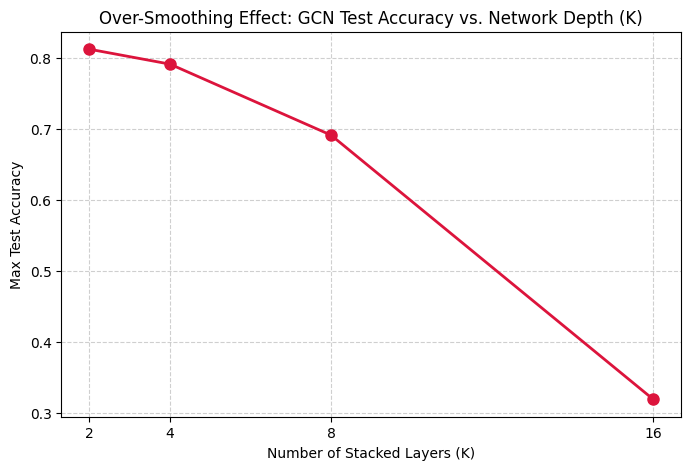

In [3]:
# --- Step 0: Install PyTorch Geometric Dependencies (Colab-safe) ---
import os
import torch
os.environ['TORCH'] = torch.__version__
print(f"Using PyTorch version: {torch.__version__}")

# Install PyG quietly
!pip install -q torch-geometric

import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Load the Cora Dataset ---
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

# --- Step 2: Define a Flexible, Stackable GCN Architecture ---
class DeepGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super(DeepGCN, self).__init__()
        self.num_layers = num_layers
        self.convs = torch.nn.ModuleList()

        if num_layers == 1:
            self.convs.append(GCNConv(in_channels, out_channels))
        else:
            # First layer maps input features to hidden dimension
            self.convs.append(GCNConv(in_channels, hidden_channels))
            # Middle hidden layers
            for _ in range(num_layers - 2):
                self.convs.append(GCNConv(hidden_channels, hidden_channels))
            # Final layer maps hidden dimension to output classes
            self.convs.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i in range(self.num_layers - 1):
            x = self.convs[i](x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.5, training=self.training)

        # Output layer without activation/dropout
        x = self.convs[-1](x, edge_index)
        return F.log_softmax(x, dim=1)

# --- Step 3: Define Training and Evaluation Functions ---
def train_and_evaluate(num_layers, epochs=150):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = DeepGCN(
        in_channels=dataset.num_features,
        hidden_channels=16,
        out_channels=dataset.num_classes,
        num_layers=num_layers
    ).to(device)

    current_data = data.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

    best_test_acc = 0.0

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(current_data.x, current_data.edge_index)
        loss = F.nll_loss(out[current_data.train_mask], current_data.y[current_data.train_mask])
        loss.backward()
        optimizer.step()

        # Evaluate performance
        model.eval()
        with torch.no_grad():
            logits = model(current_data.x, current_data.edge_index)
            pred = logits.argmax(dim=1)

            # Test accuracy check
            test_correct = pred[current_data.test_mask] == current_data.y[current_data.test_mask]
            test_acc = int(test_correct.sum()) / int(current_data.test_mask.sum())

            if test_acc > best_test_acc:
                best_test_acc = test_acc

    print(f"Finished training GCN with K = {num_layers:2d} Layers. Max Test Accuracy: {best_test_acc * 100:.2f}%")
    return best_test_acc

# --- Step 4: Run Experiments for K = 2, 4, 8, 16 ---
K_values = [2, 4, 8, 16]
accuracies = []

print("Starting GCN multi-layer simulation script...")
for k in K_values:
    acc = train_and_evaluate(num_layers=k)
    accuracies.append(acc)

# --- Step 5: Plot Test Accuracy vs. K ---
plt.figure(figsize=(8, 5))
plt.plot(K_values, accuracies, marker='o', color='crimson', linewidth=2, markersize=8)
plt.title('Over-Smoothing Effect: GCN Test Accuracy vs. Network Depth (K)', fontsize=12)
plt.xlabel('Number of Stacked Layers (K)', fontsize=10)
plt.ylabel('Max Test Accuracy', fontsize=10)
plt.xticks(K_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()